# Section 1 — CLO ETFs: the democratization dataset

Thin driver notebook: all logic lives in `src/etf/`. This notebook only imports, orchestrates (scrape -> analysis -> viz), and displays. Run `make etf` from the repo root to do the same thing headlessly.

Scraping hits live network endpoints (Janus Henderson full-holdings pages, Yahoo Finance via `yfinance`, FRED). Re-running is safe: `CachedSession` skips URLs already in `data/raw/_manifest.csv`, and `scrape_holdings.py` / `scrape_nav_flows.py` are idempotent.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.etf import (
    scrape_holdings, scrape_nav_flows,
    analysis_flows, analysis_nav_dislocation, analysis_tranche_panel, analysis_manager_league, analysis_returns,
    viz_growth, viz_dislocation, viz_tranche, viz_league, viz_returns,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)
Set `RUN_SCRAPE = True` to hit the network; otherwise this notebook runs entirely from whatever is already cached in `data/interim/`.

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_holdings.run()
    scrape_nav_flows.run()

## Analysis (interim -> final)

In [3]:
flows = analysis_flows.run()
dislocation = analysis_nav_dislocation.run()
tranche = analysis_tranche_panel.run()
league = analysis_manager_league.run()
returns = analysis_returns.run()

NAV snapshot history has only 1 distinct date(s); need >=2 to compute flows. Run scrape_nav_flows.py again on a later day.


flows_monthly is empty; flow_event_study returns an empty frame rather than interpolating


8 fund(s) have <30 days of NAV history; distribution stats are provisional: ['CLOA', 'CLOB', 'CLOD', 'CLOI', 'CLOZ', 'ICLO', 'JAAA', 'JBBB']


dropping 25/843 holdings rows as non-tranche line items or implausible marks (bad CUSIP format or price outside (80.0, 112.0))


holdings history has <2 distinct dates; deal_movers needs at least two scrape_holdings.py runs


holdings history has <2 distinct dates; tranche_turnover needs at least two scrape_holdings.py runs


## Viz (final -> figures/)

flows_monthly is empty (need >=2 NAV snapshot dates); skipping viz_monthly_flows for now


dropping 25/843 holdings rows as non-tranche line items or implausible marks (bad CUSIP format or price outside (80.0, 112.0))


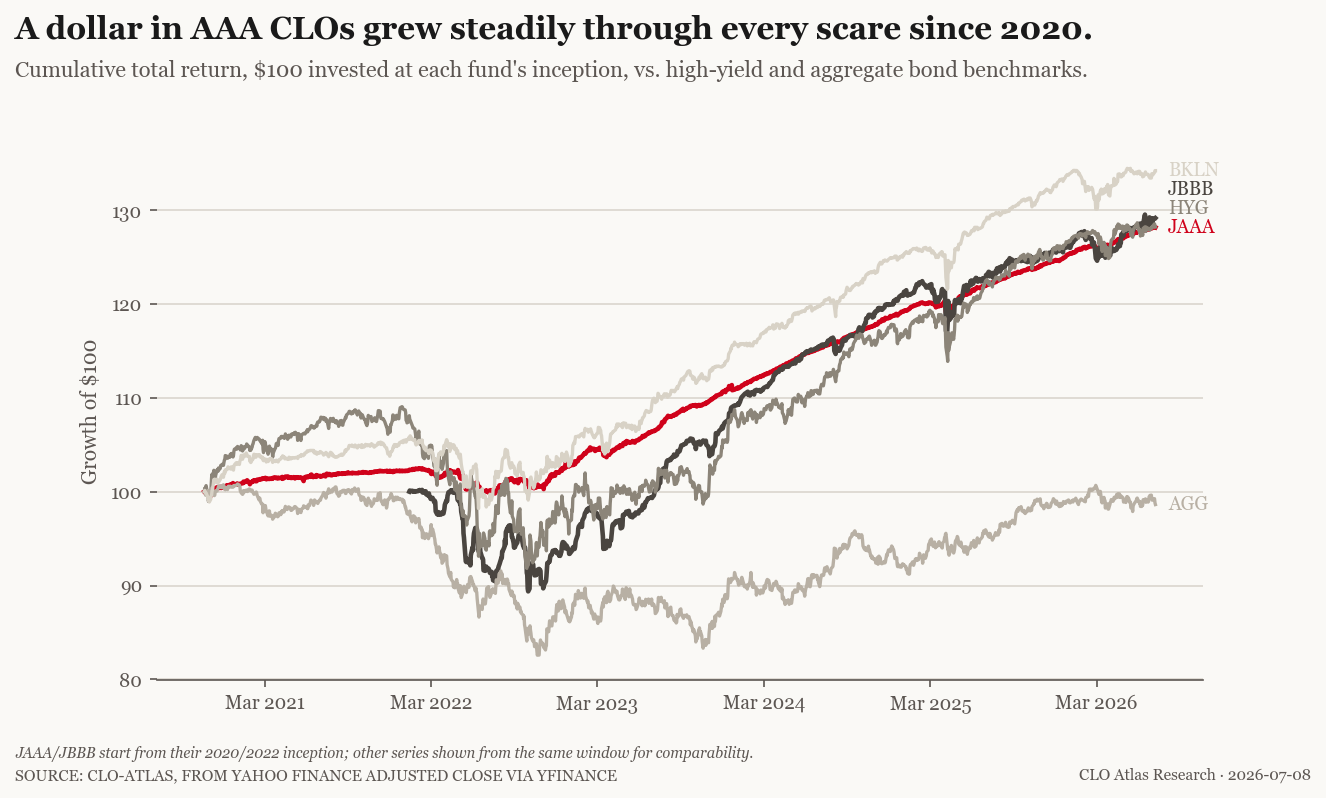

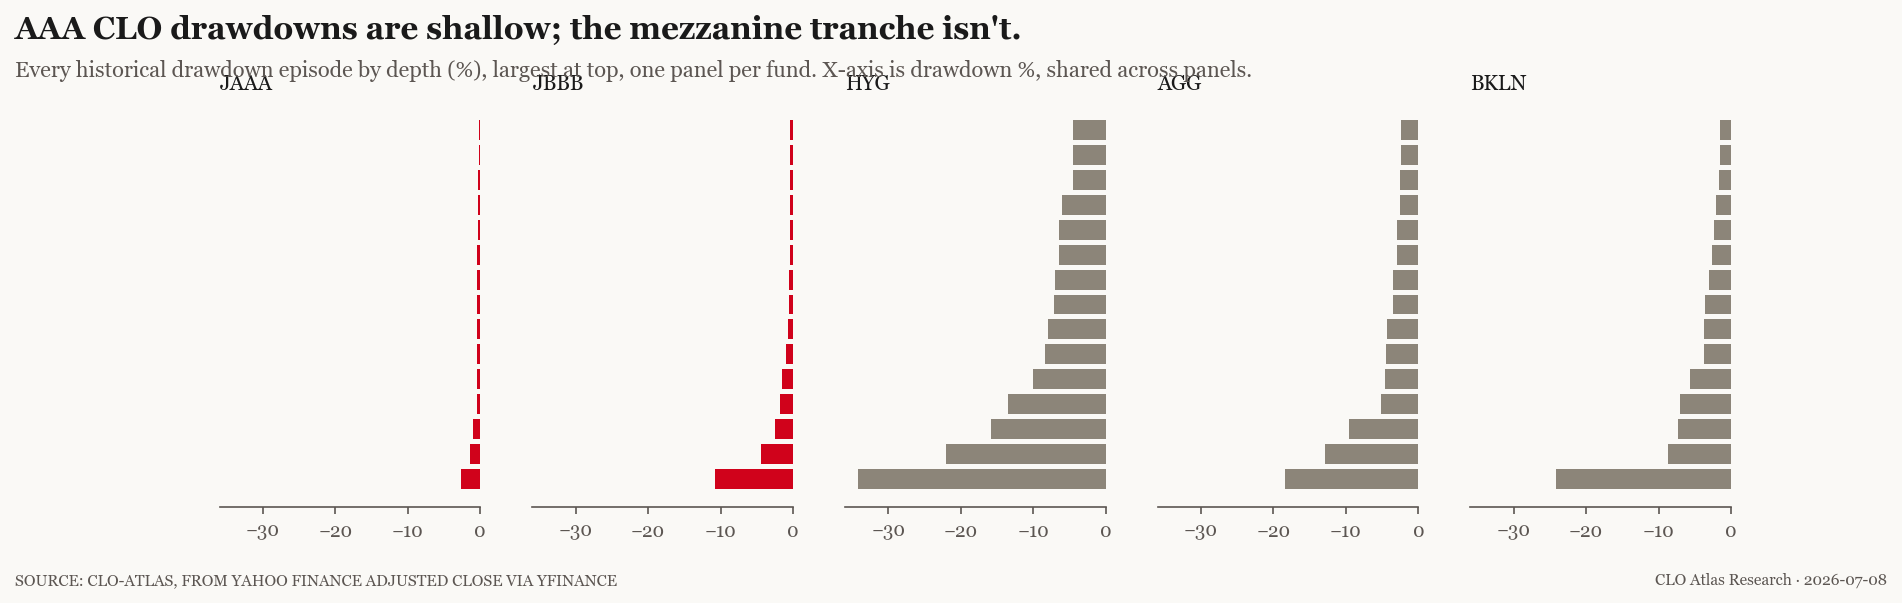

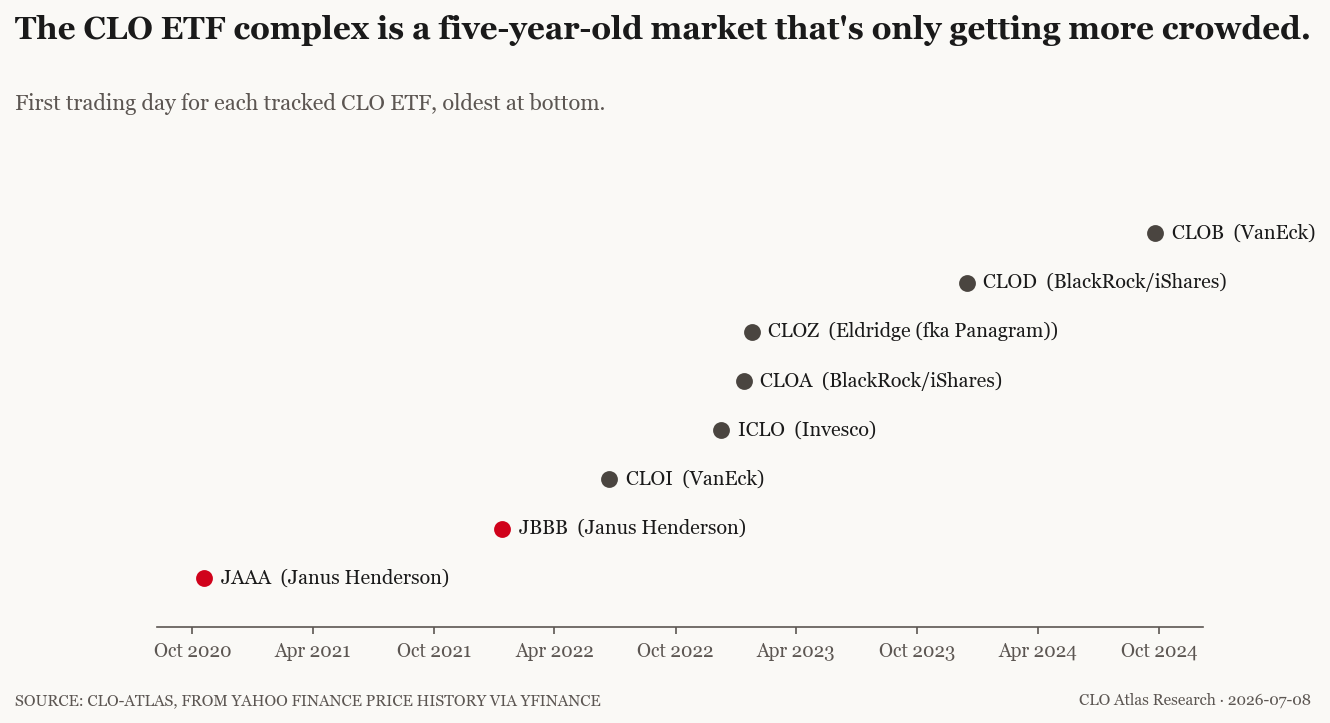

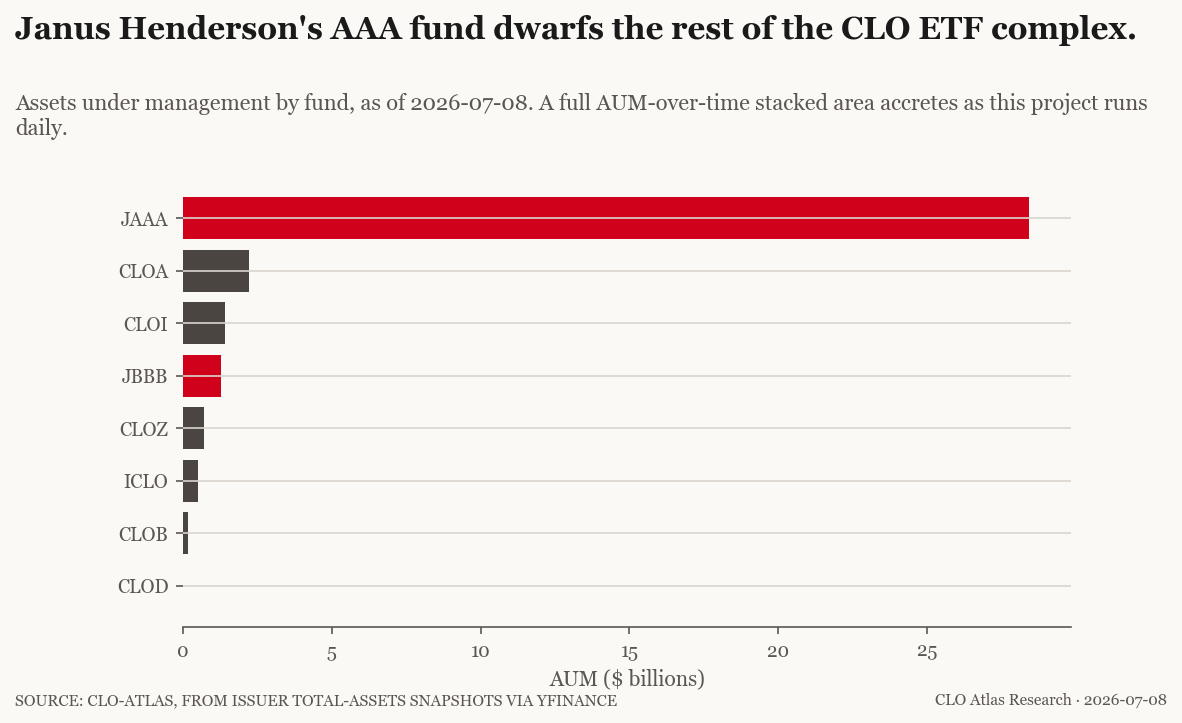

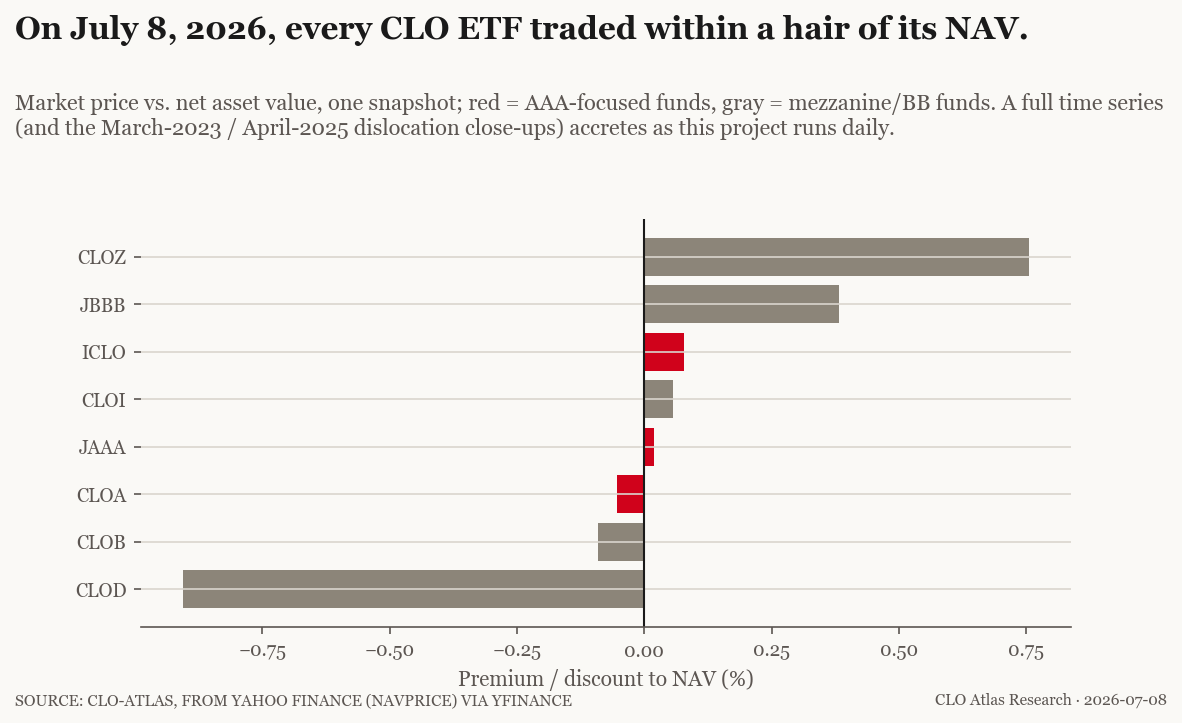

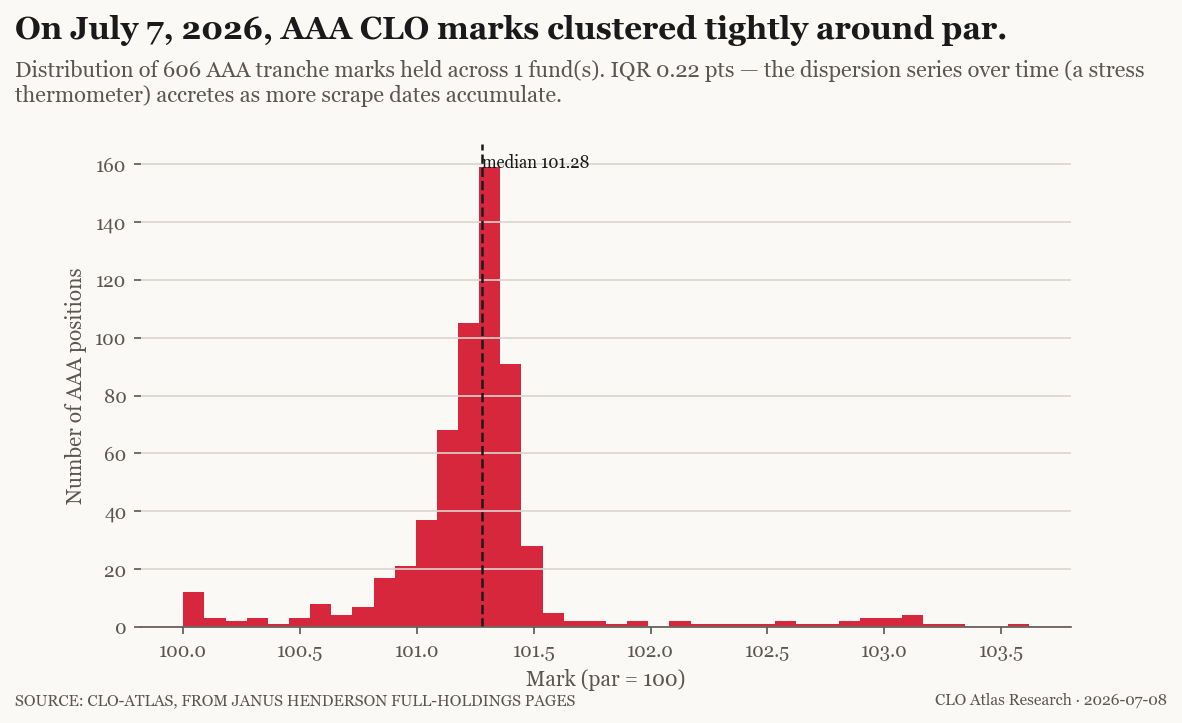

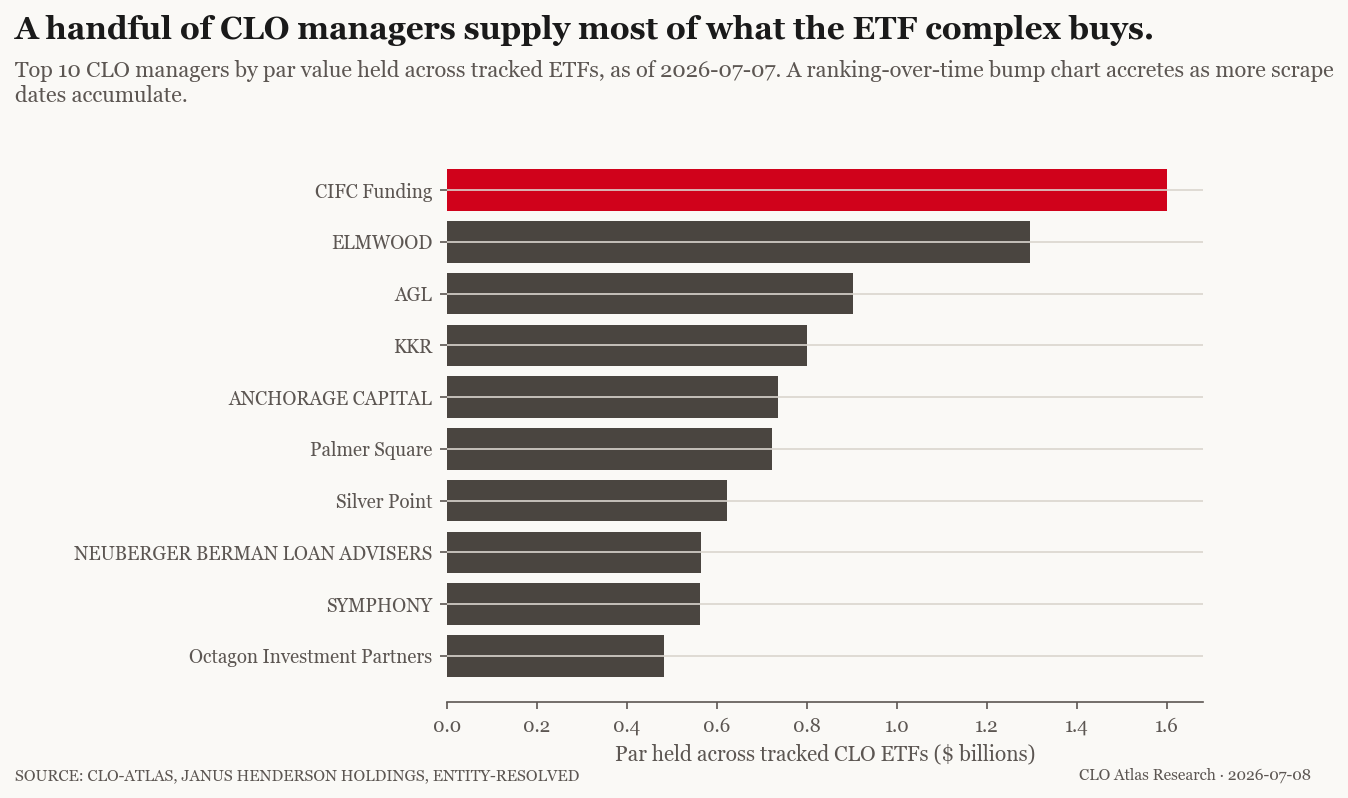

In [4]:
viz_returns.run()
viz_growth.run()
viz_dislocation.run()
viz_tranche.run()
viz_league.run()

## Exhibits

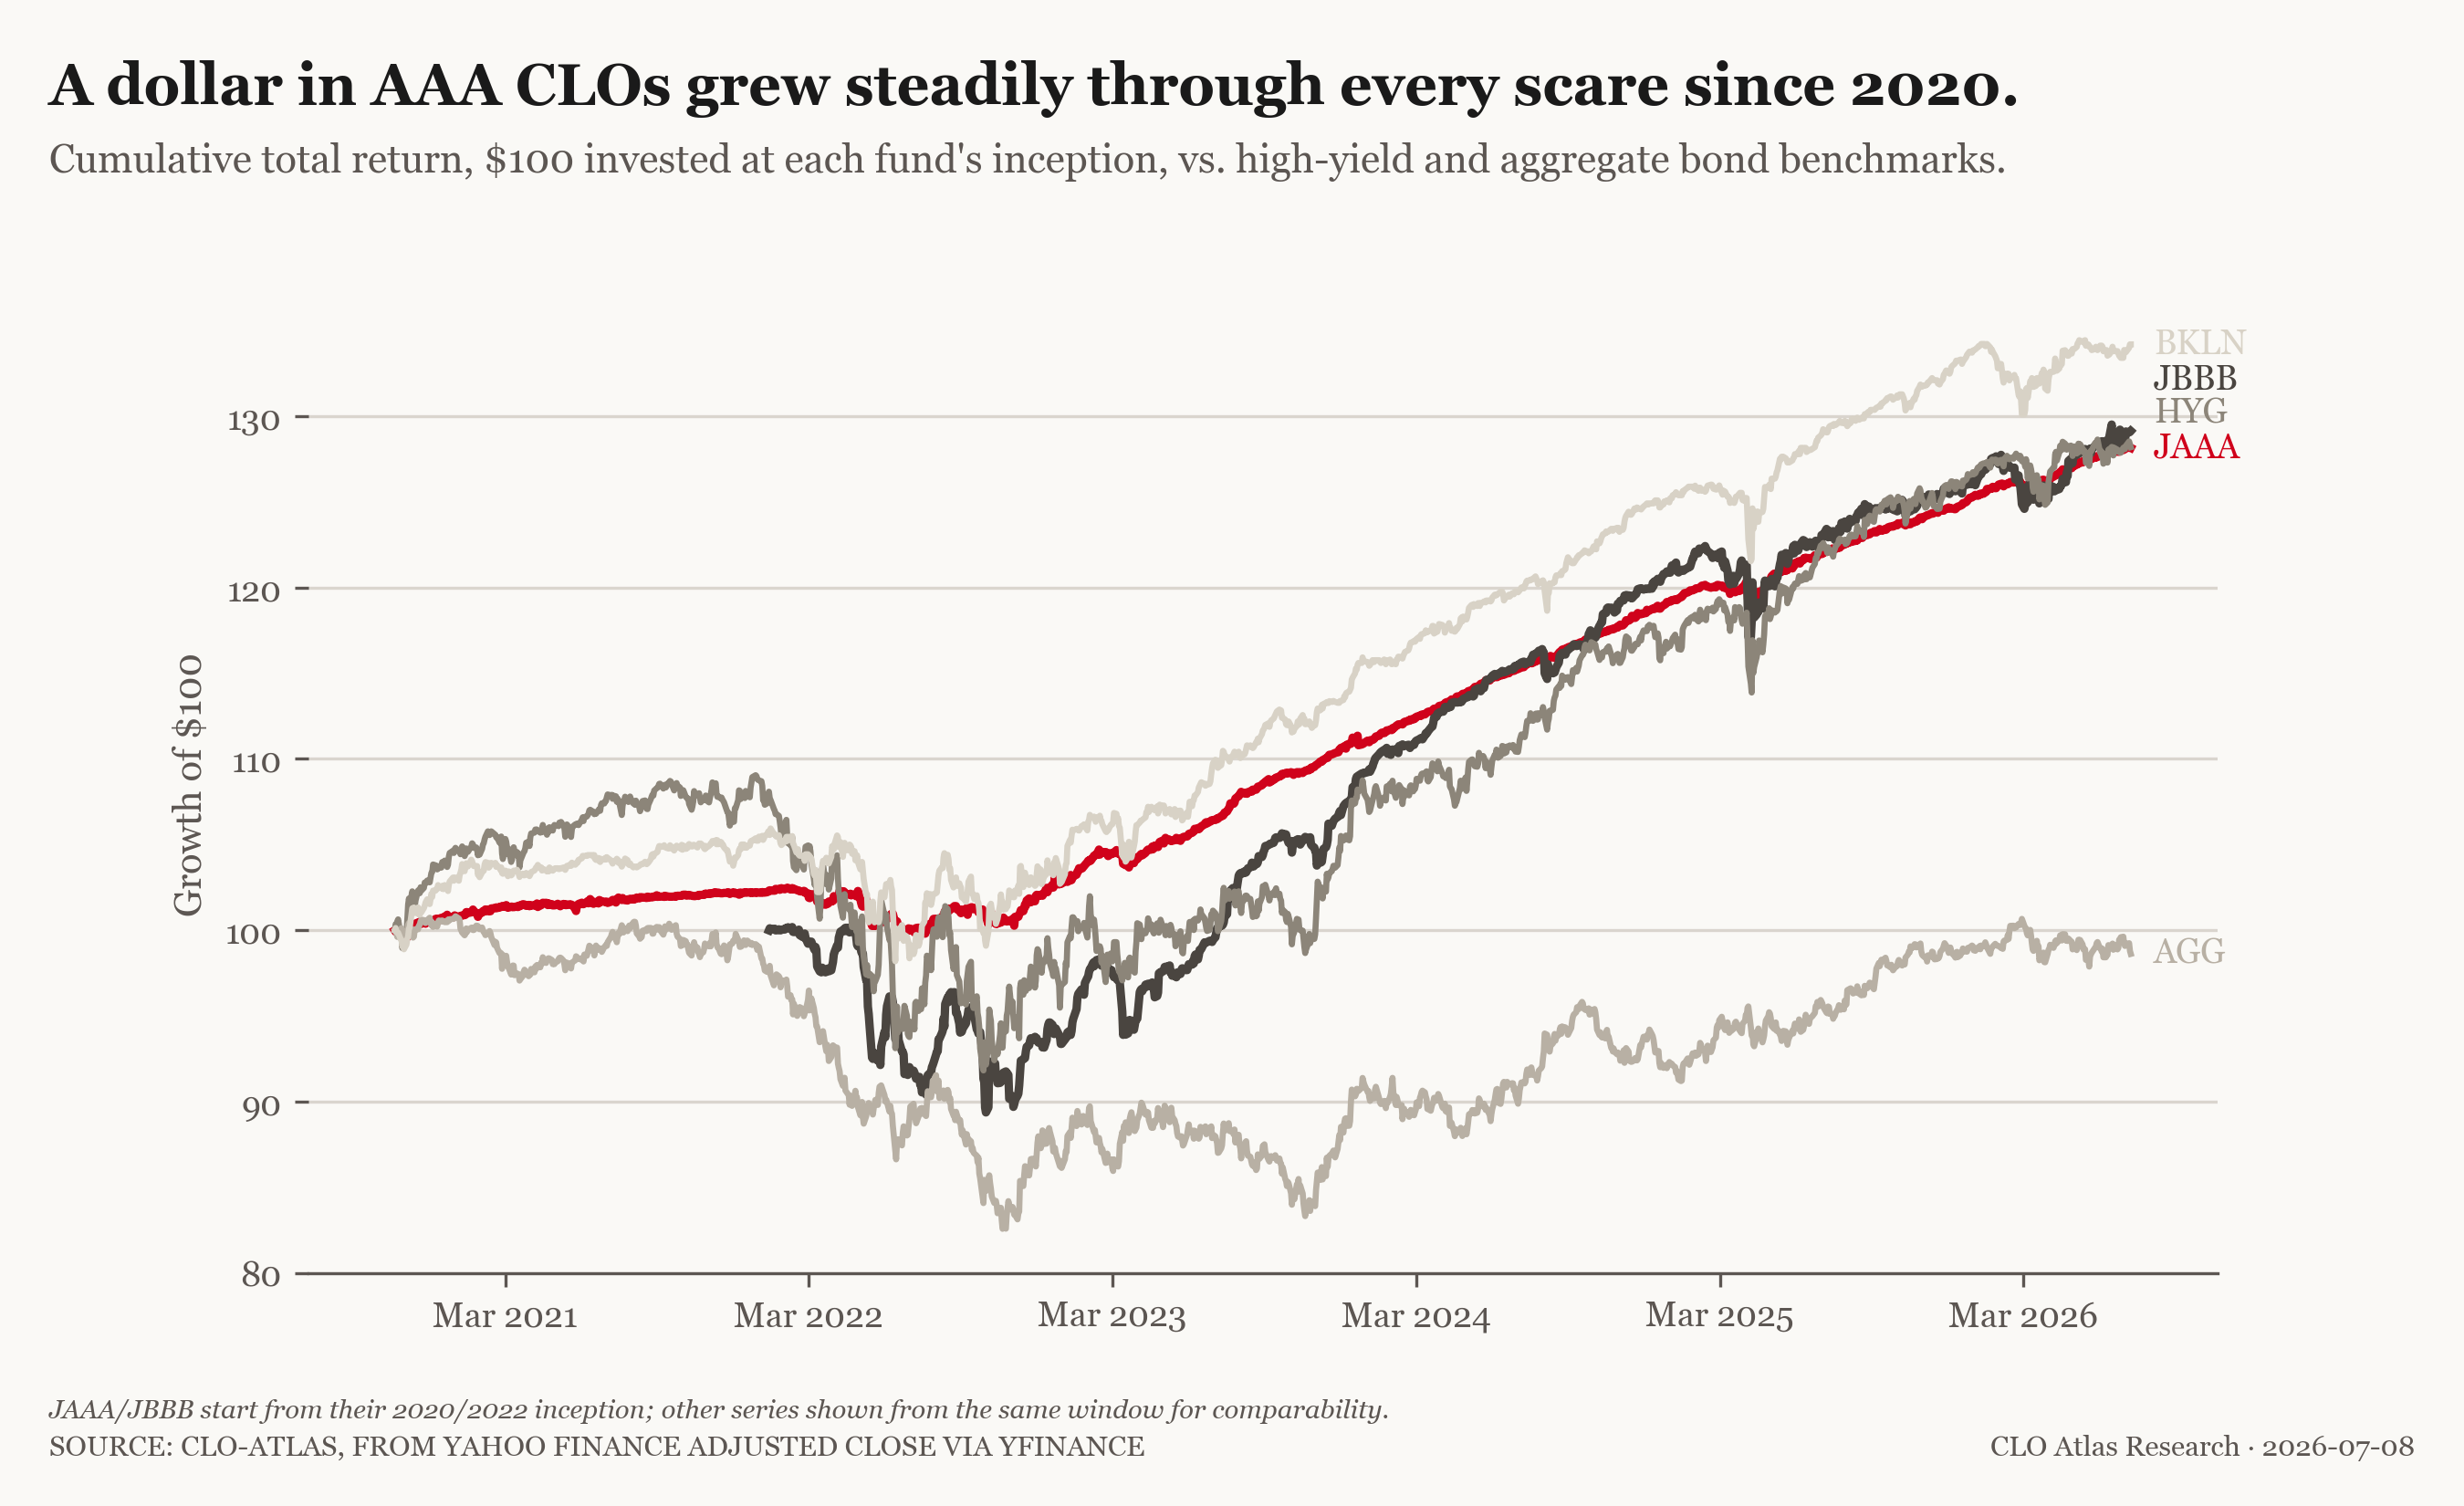

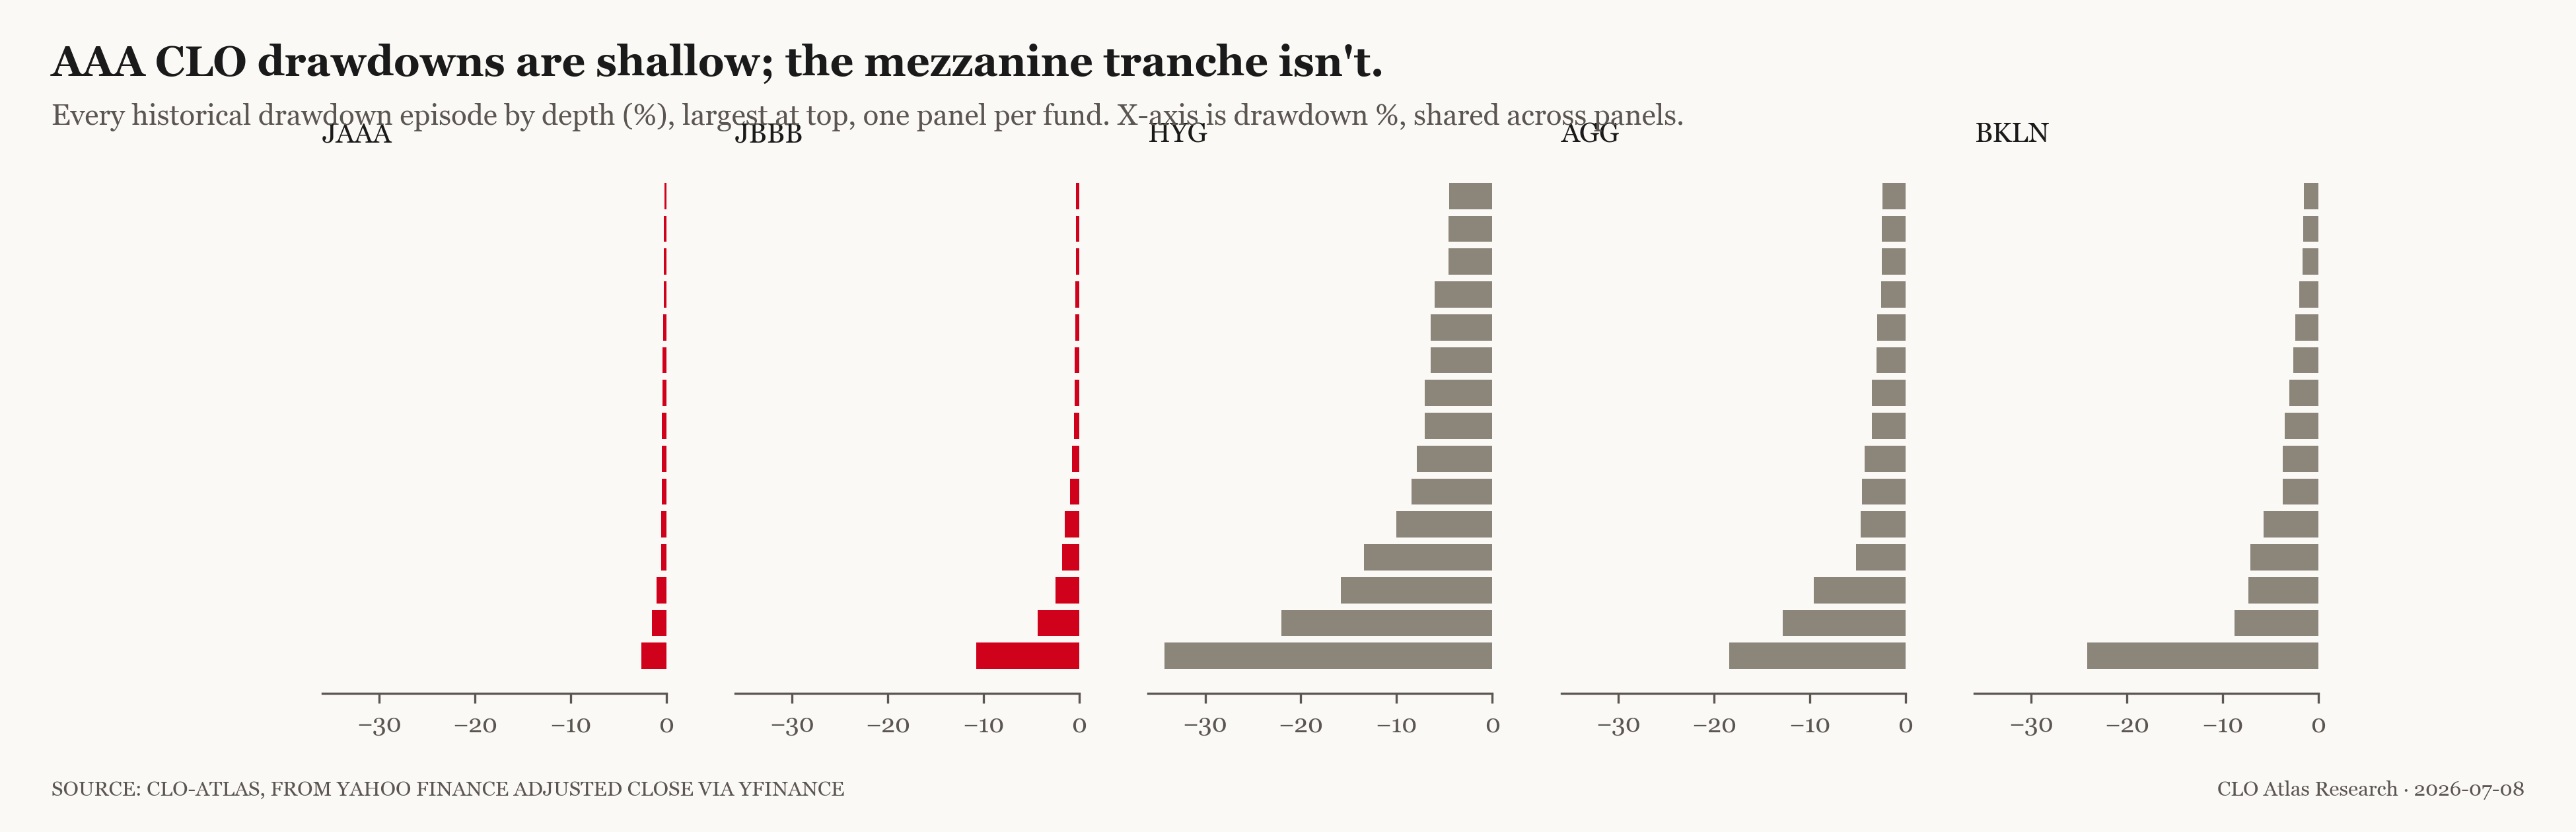

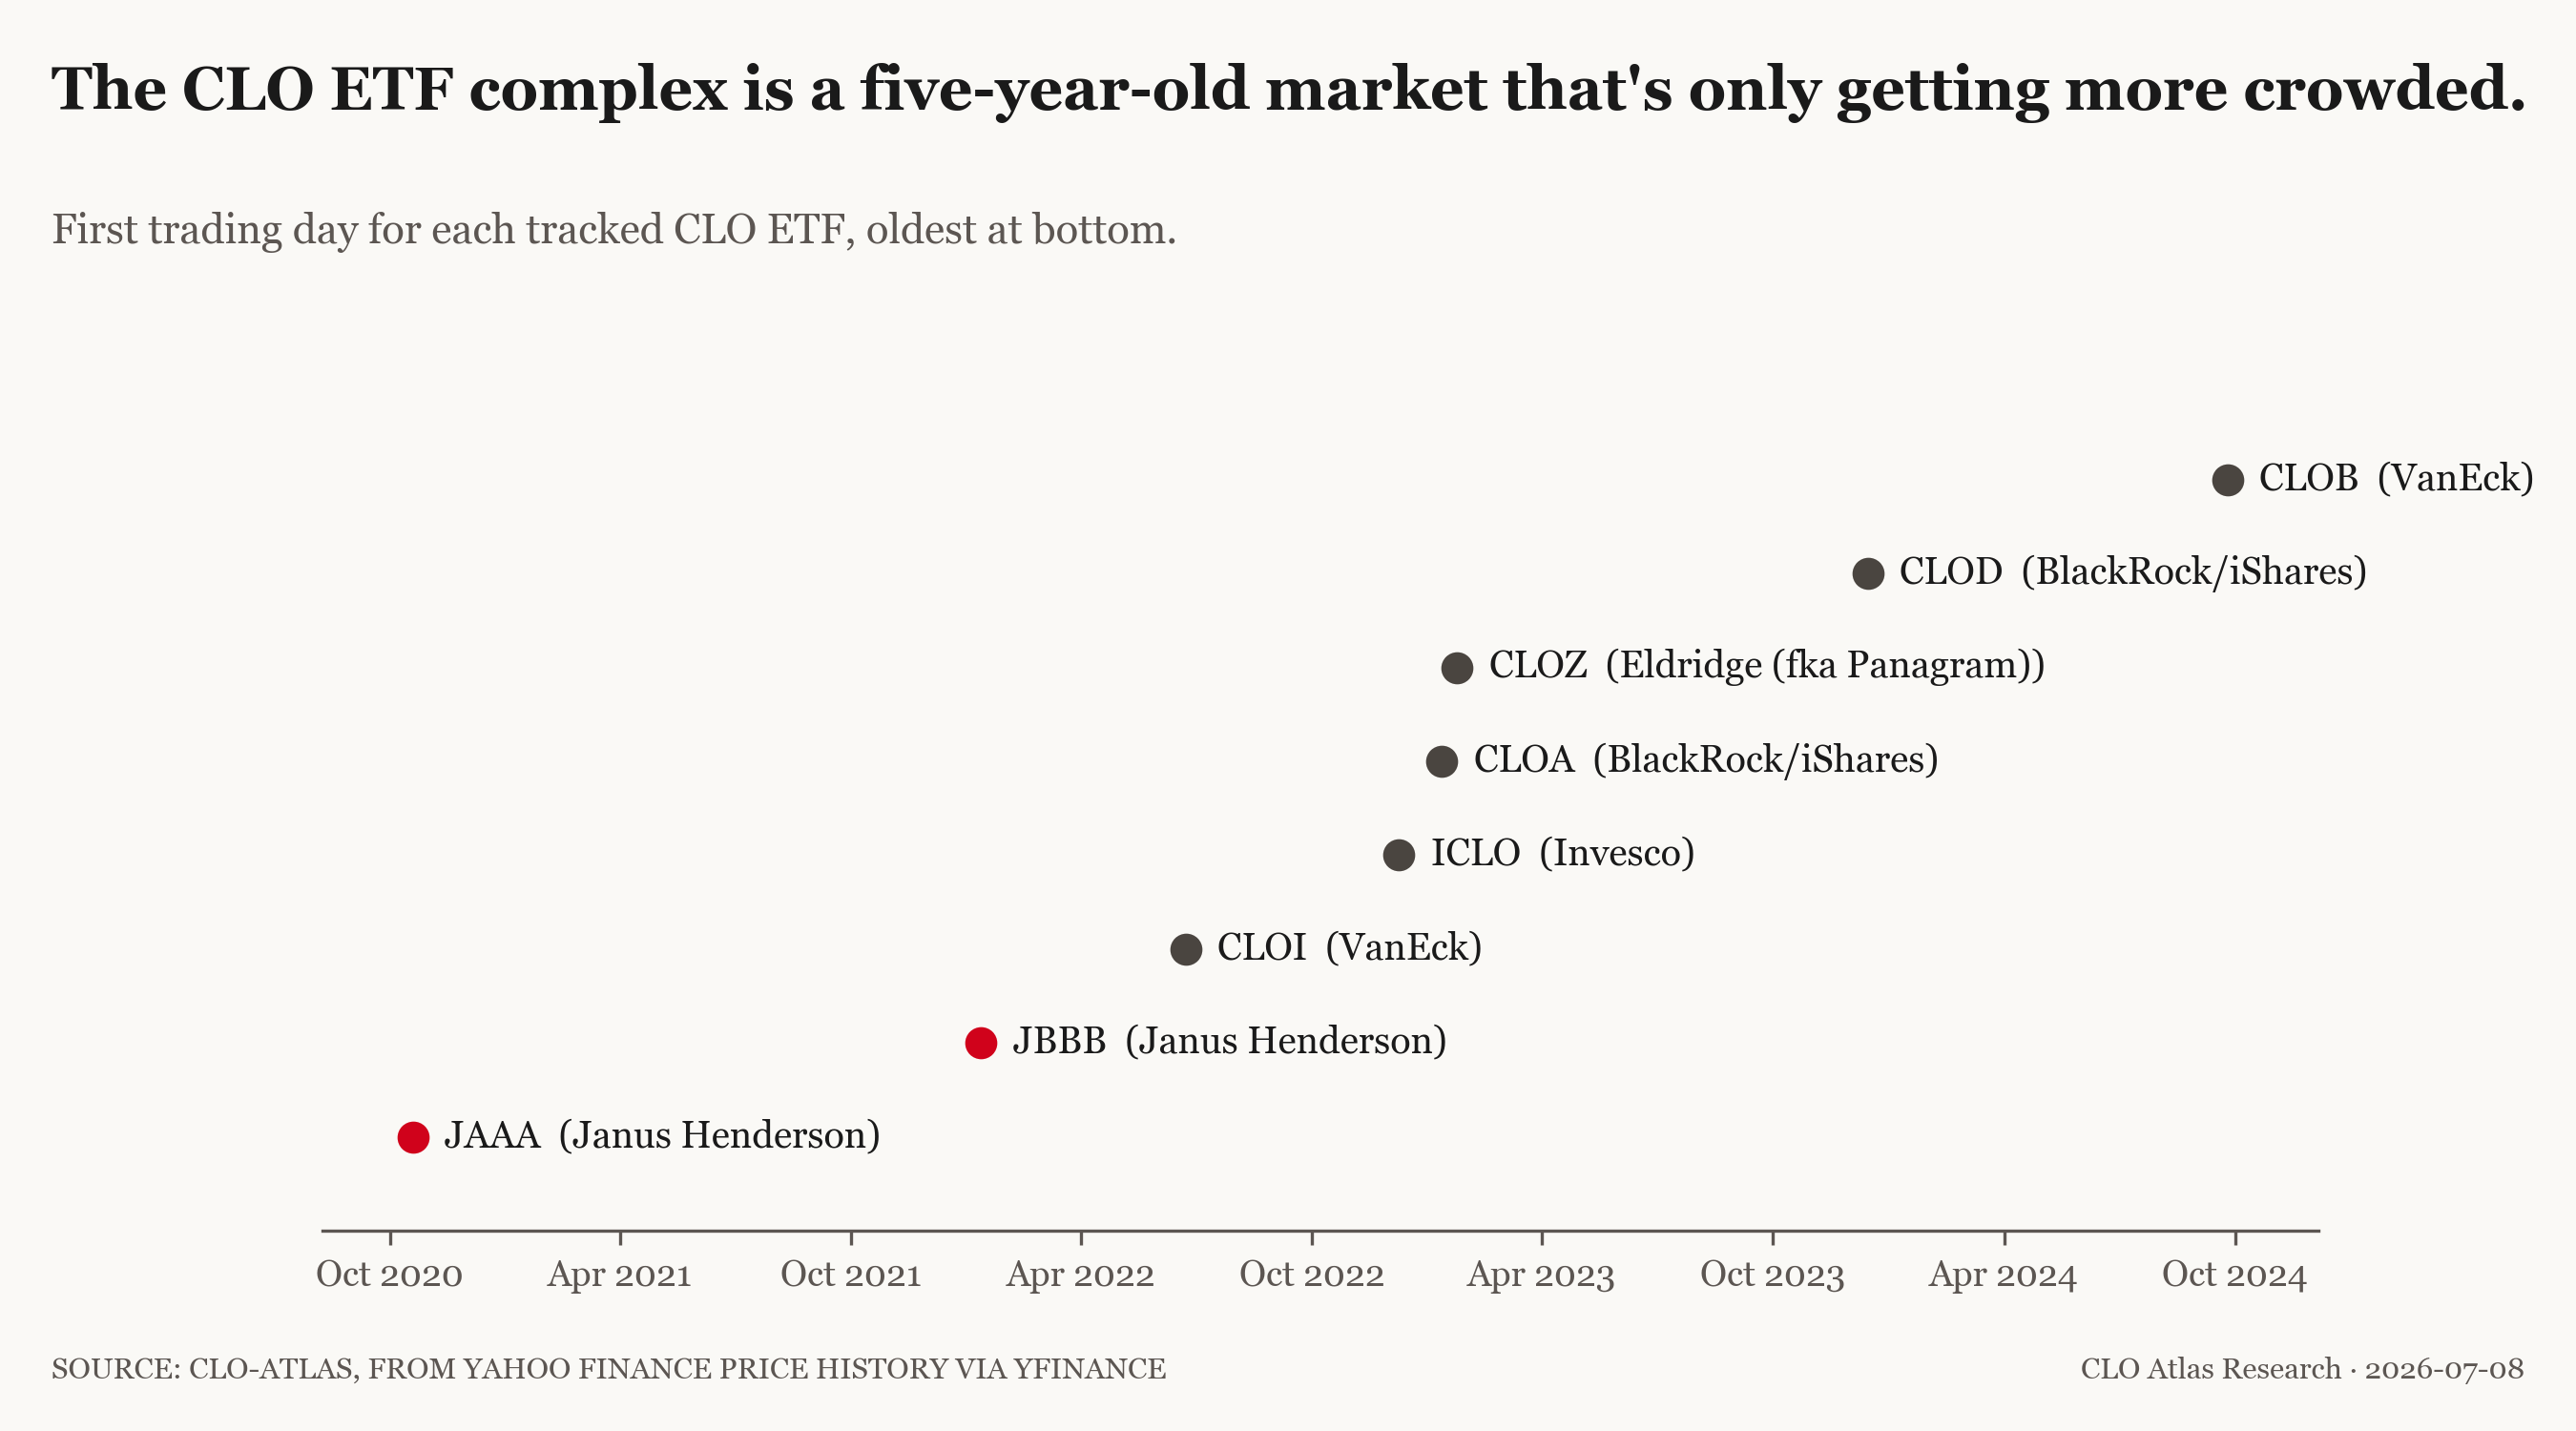

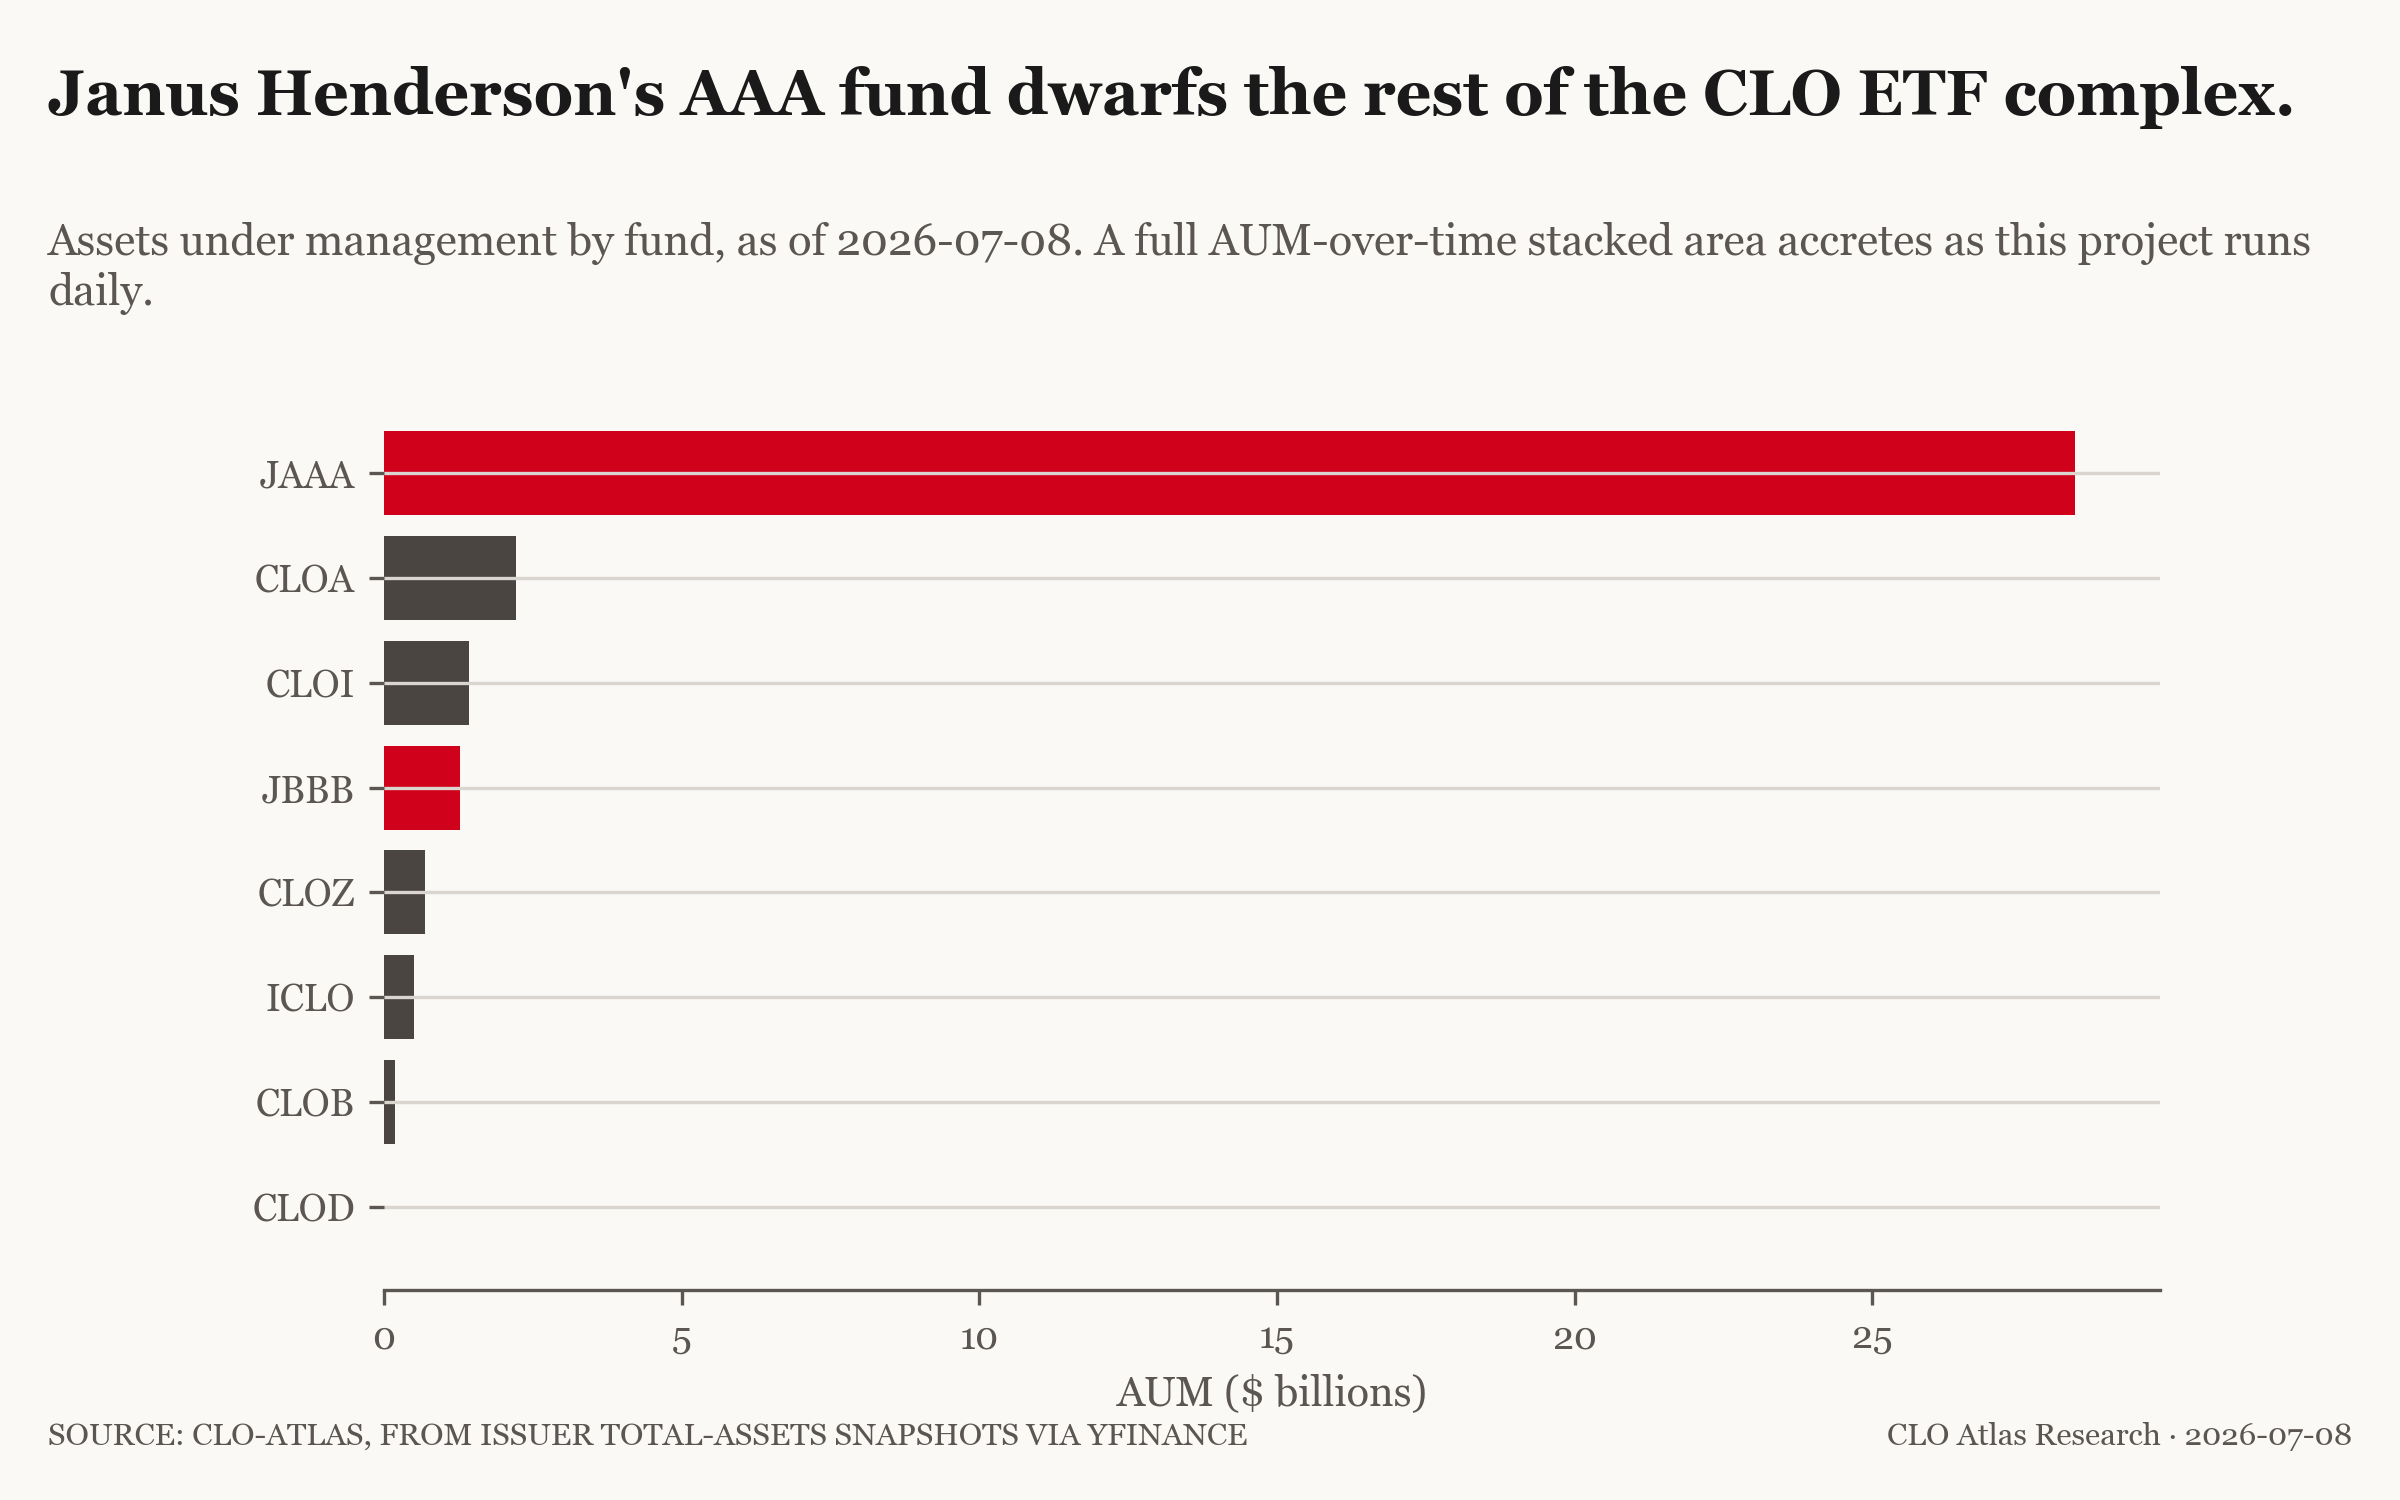

[skipped — not generated this run] viz_monthly_flows


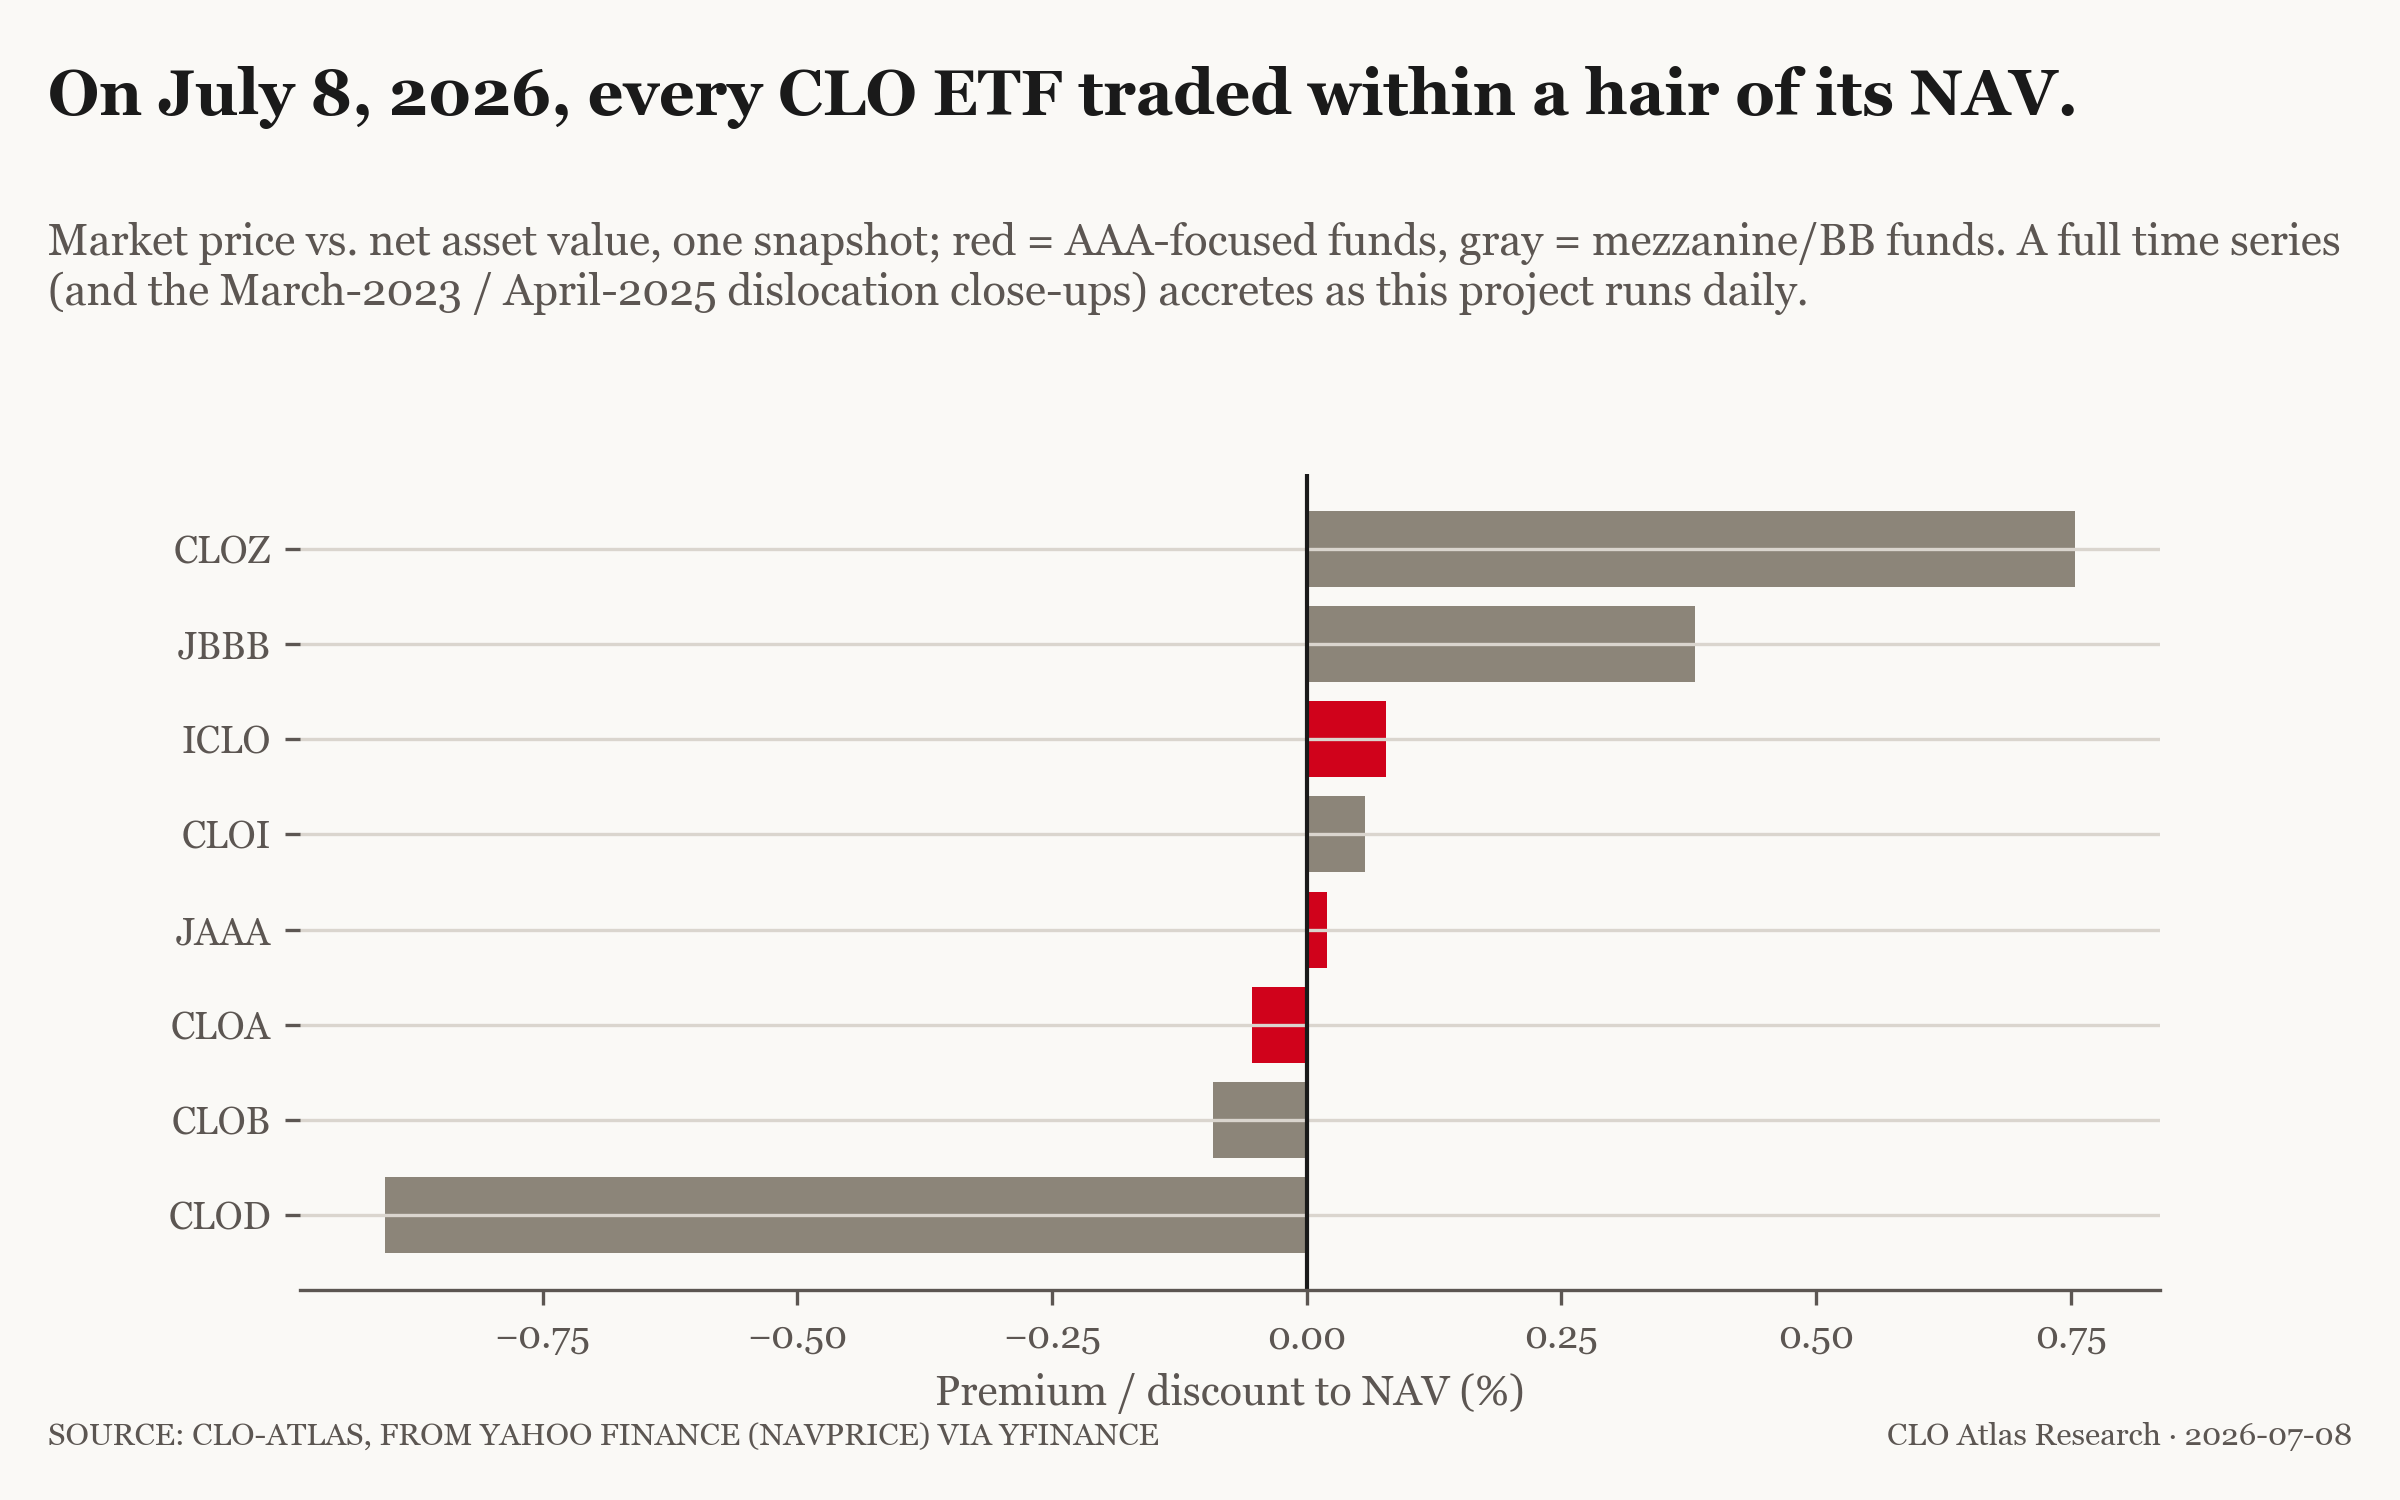

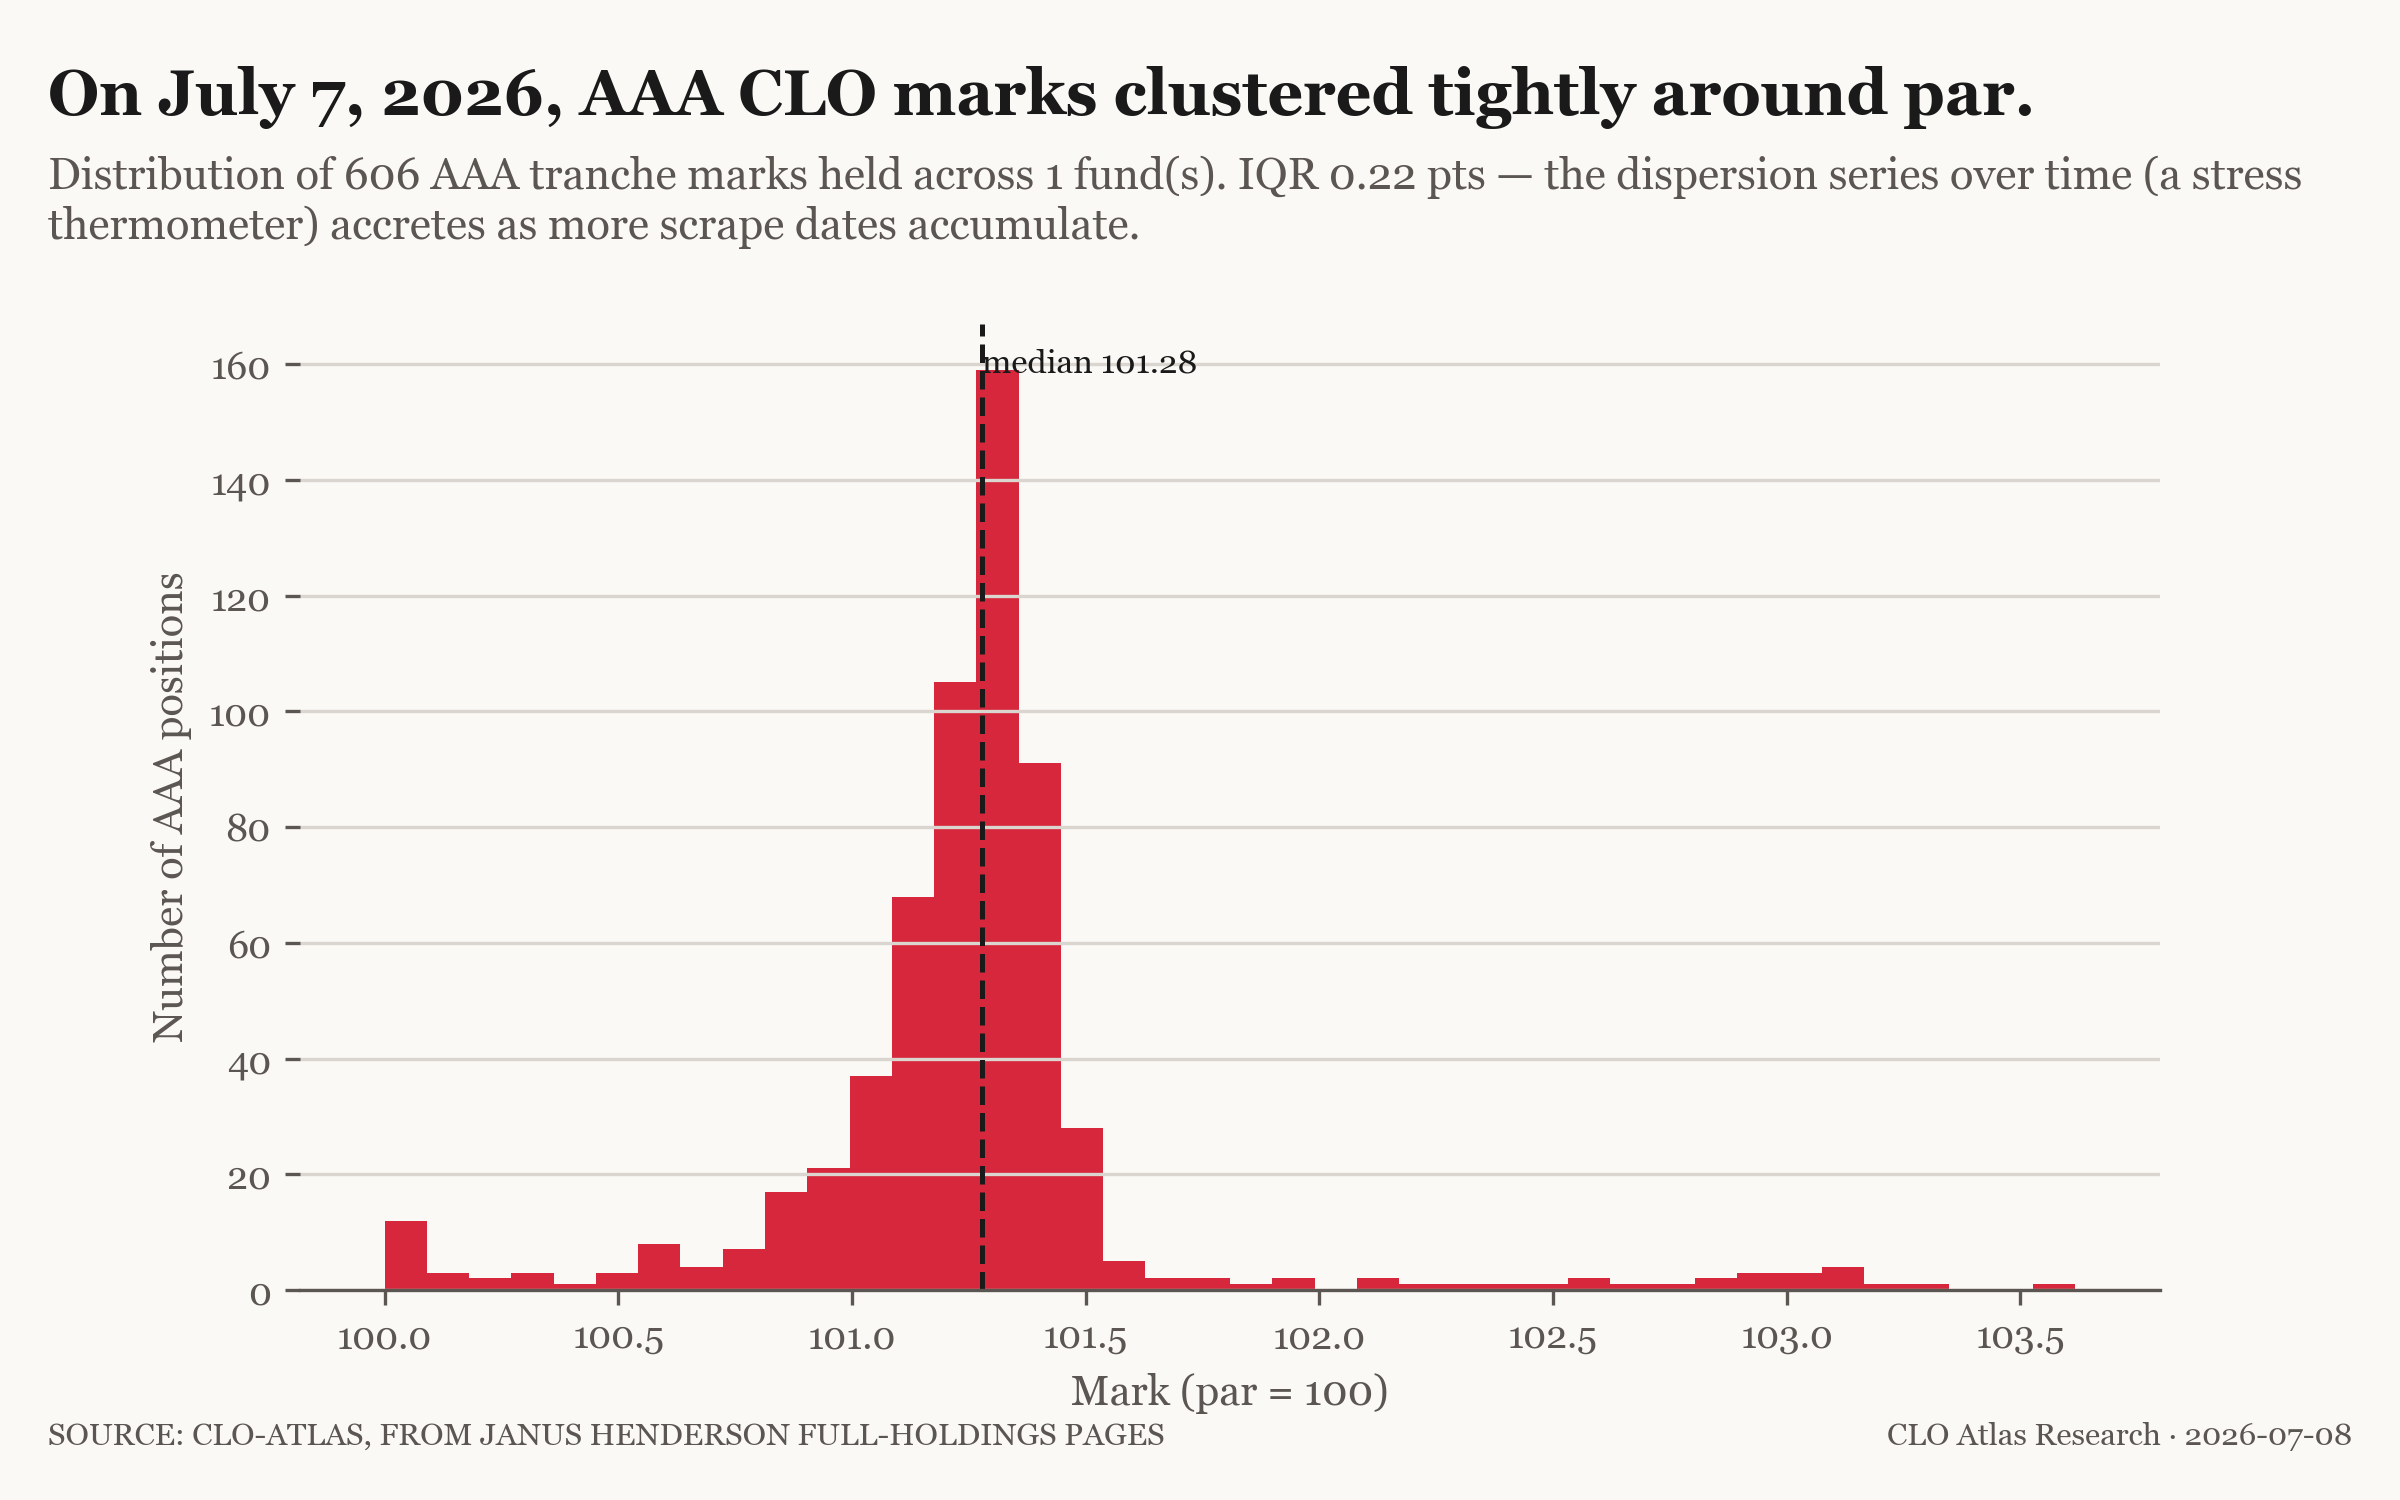

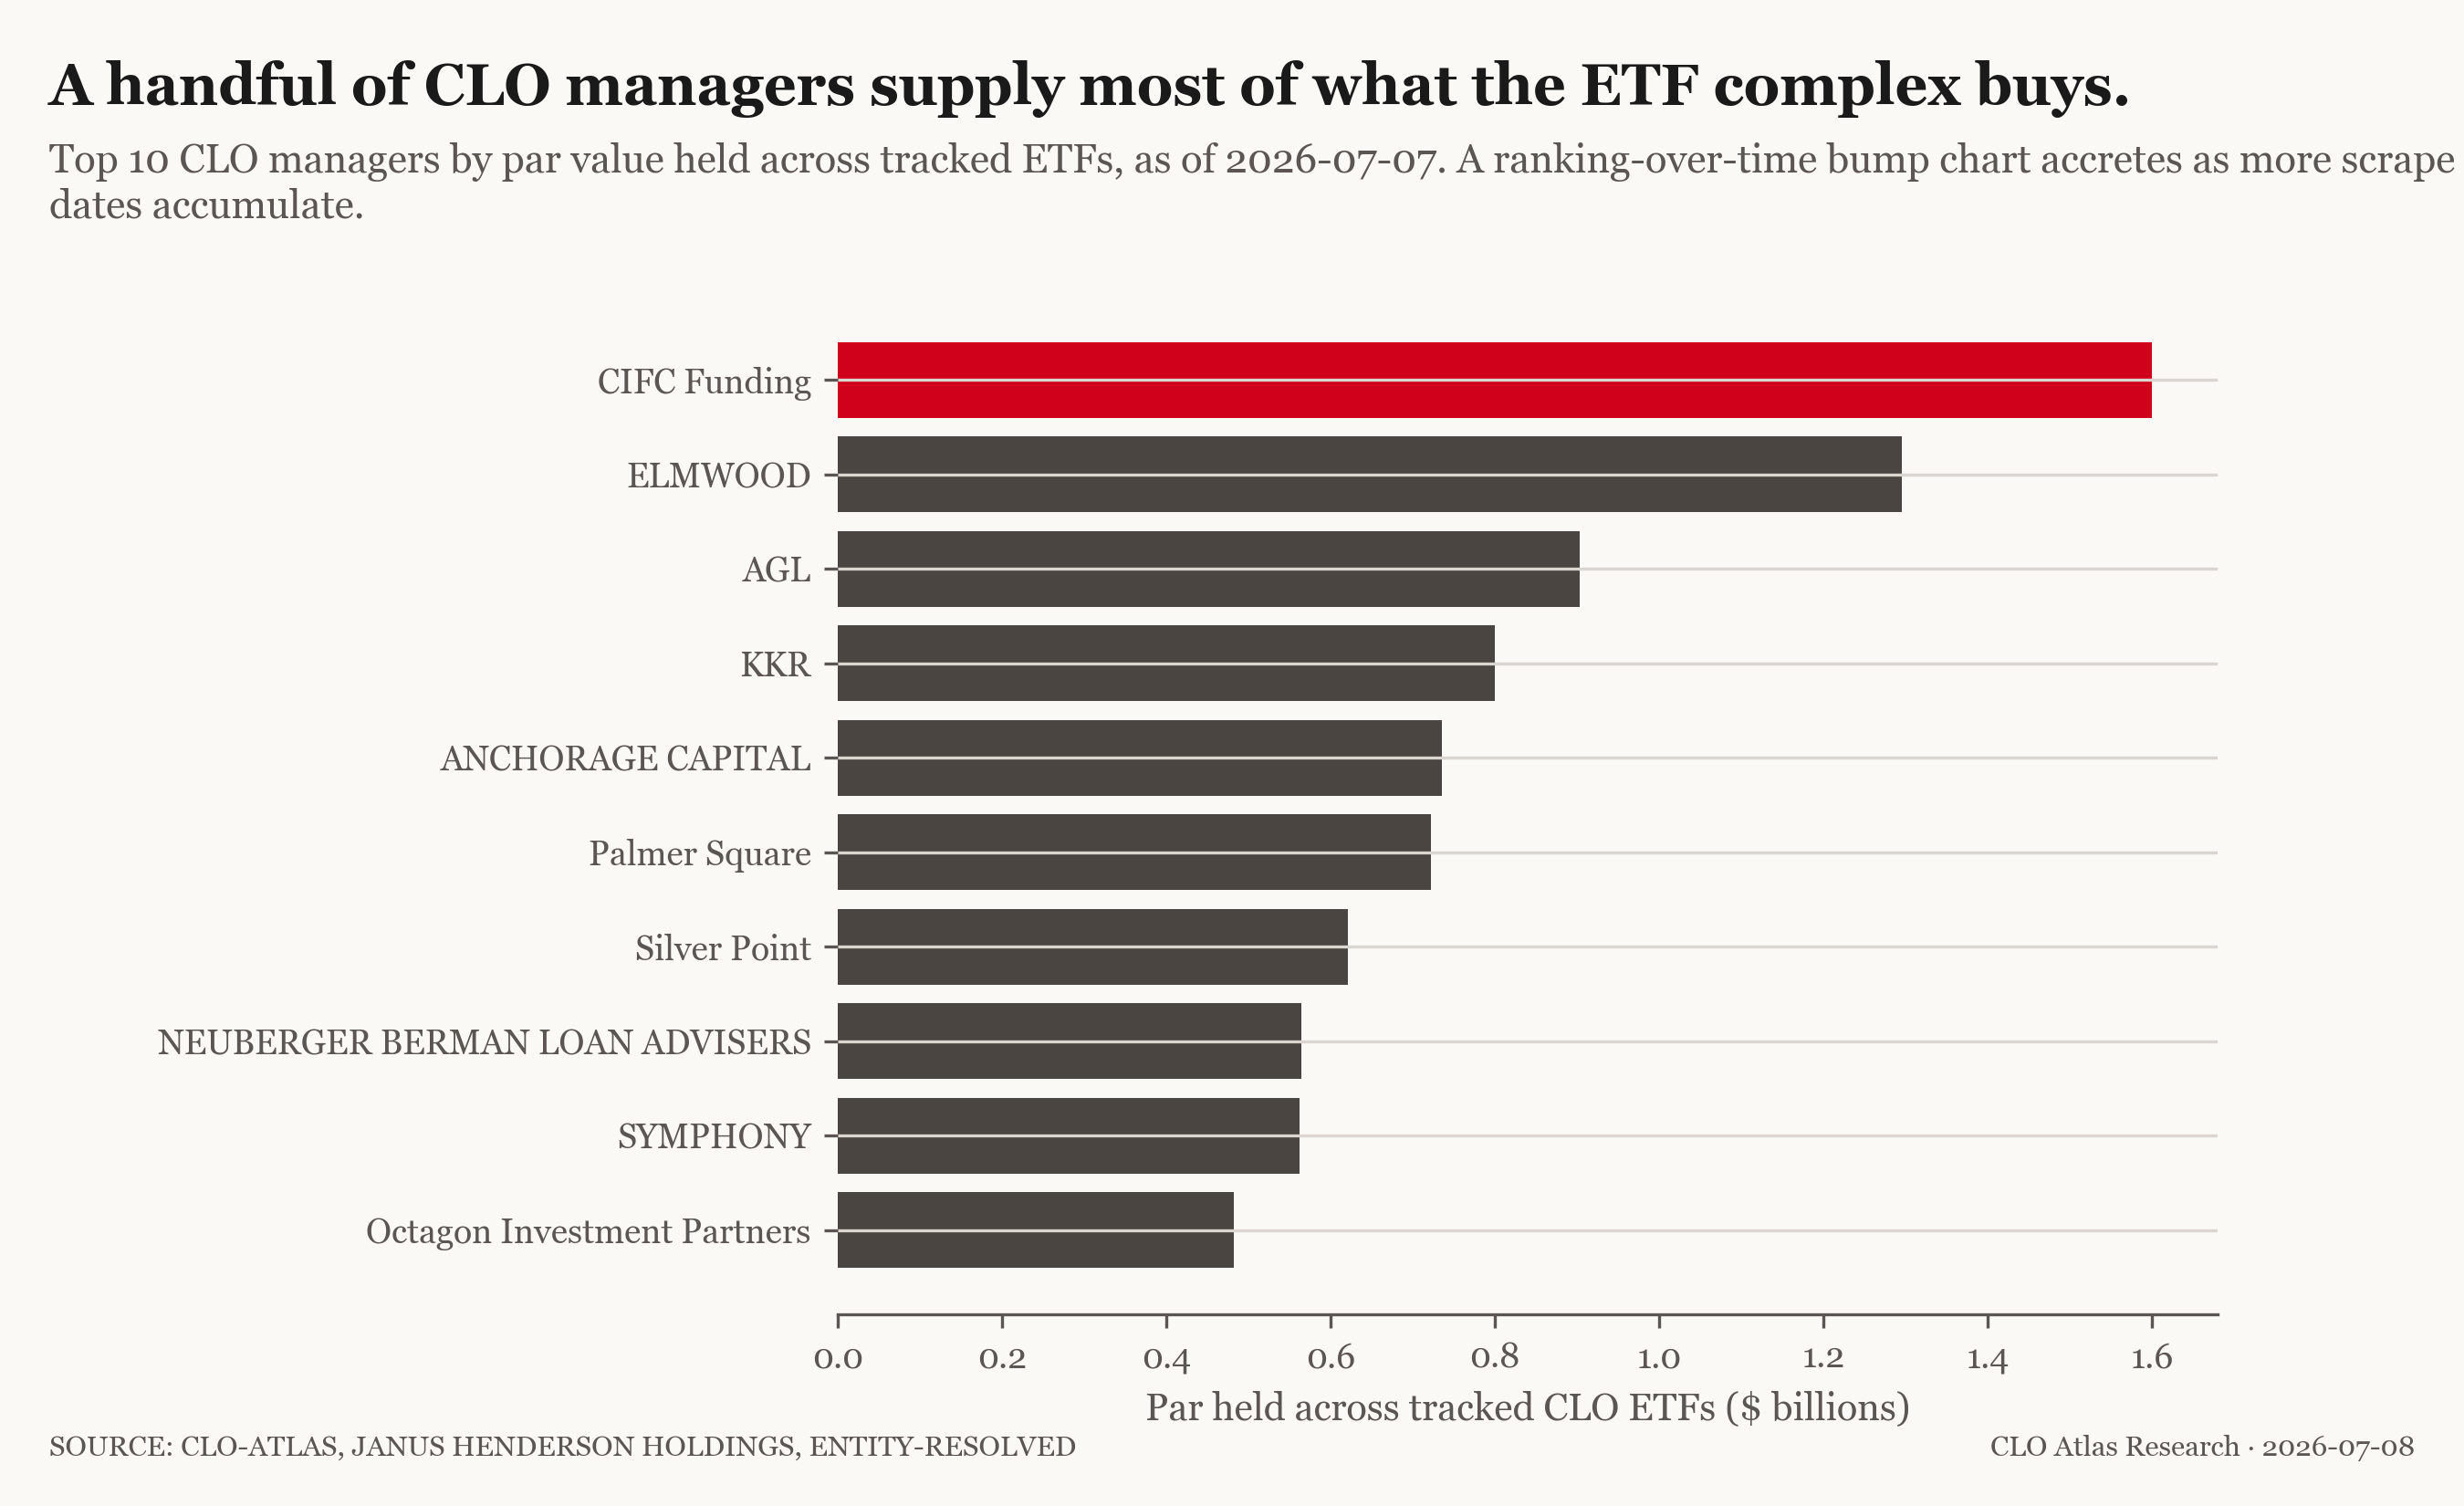

In [5]:
for name in [
    "viz_growth_of_100", "viz_drawdown_small_multiples",
    "viz_launch_timeline", "viz_current_aum", "viz_monthly_flows",
    "viz_current_premium_discount",
    "viz_aaa_mark_distribution",
    "viz_top10_managers",
]:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")